In [25]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# 1. Cargar datos

[Link](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data?select=WA_Fn-UseC_-Telco-Customer-Churn.csv)

In [26]:
DATA_PATH = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

# 2. EDA básico

In [27]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
print(df["Churn"].value_counts())

(7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod

# 3. Preprocesamiento

In [28]:
# (a) Borrardo de variables irrelevantes
df = df.drop(columns=["customerID"])

In [29]:
# (b) Convertir total charges a numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [30]:
# (c) Definir target and predictores
target_col = "Churn"
y = (df[target_col] == "Yes").astype(int).values  # binary 0/1

# Separar features
X = df.drop(columns=[target_col])

# Identificar variables numericas vs categoricas
num_features = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_features = [c for c in X.columns if c not in num_features]

In [31]:
num_features

['tenure', 'MonthlyCharges', 'TotalCharges']

In [32]:
cat_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [33]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


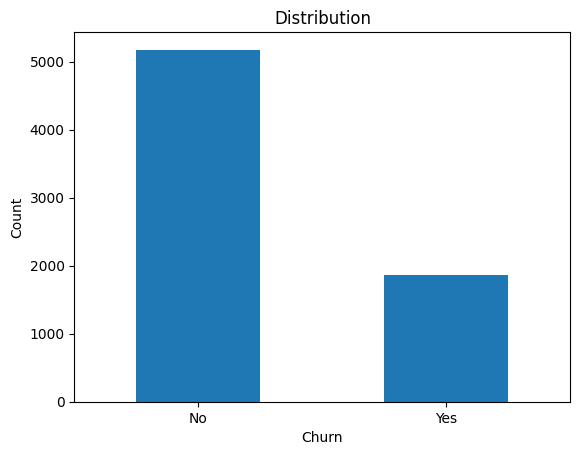

In [34]:
counts = df['Churn'].value_counts()
counts.plot.bar(rot=0) # rot=0 prevents x-axis labels from rotating
plt.title('Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

# 4. Construir pipeline de preprocessing

In [35]:
# Imputación de missing values
num_imputer = SimpleImputer(strategy="median")
# Para categorías, rellenamos los valores faltantes con un valor especial.
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")

In [36]:
# Encoders / scalers
num_scaler = StandardScaler()
# OneHotEncoder 
cat_encoder = OneHotEncoder(handle_unknown="ignore")

In [37]:

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", num_imputer), ("scaler", num_scaler)]), num_features),
        ("cat", Pipeline([("imputer", cat_imputer), ("ohe", cat_encoder)]), cat_features),
    ],
    remainder="drop",  # drop any other columns
)

# 5. Train / validation / test split

In [38]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

In [39]:
# Ajustar preprocessing en el conjunto training
preprocessor.fit(X_train)

# Transformamos
X_train_prep = preprocessor.transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

input_dim = X_train_prep.shape[1]

In [40]:
X_train_prep.shape

(5088, 46)

# 6. Definimos nuestro modelo NN

In [41]:
def make_model(input_dim, dropout_rate=0.3, hidden_units=[64, 32]):
    inputs = layers.Input(shape=(input_dim,))
    x = inputs
    
    for units in hidden_units:
        x = layers.Dense(units, activation="relu")(x)
        x = layers.Dropout(dropout_rate)(x)
        
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = models.Model(inputs=inputs, outputs=outputs)

    return model

model = make_model(input_dim=input_dim, dropout_rate=0.3, hidden_units=[64, 64, 32,])

In [42]:
@tf.keras.utils.register_keras_serializable()
class BinaryF1Score(tf.keras.metrics.Metric):
    """F1 binario global: acumula la matriz de confusión de toda la época."""

    def __init__(self, threshold=0.5, name="f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.true_positives = self.add_weight(name="true_positives", initializer="zeros")
        self.false_positives = self.add_weight(name="false_positives", initializer="zeros")
        self.false_negatives = self.add_weight(name="false_negatives", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        y_pred = tf.cast(tf.reshape(y_pred, [-1]) >= self.threshold, tf.float32)

        self.true_positives.assign_add(tf.reduce_sum(y_true * y_pred))
        self.false_positives.assign_add(tf.reduce_sum((1.0 - y_true) * y_pred))
        self.false_negatives.assign_add(tf.reduce_sum(y_true * (1.0 - y_pred)))

    def result(self):
        precision = tf.math.divide_no_nan(self.true_positives, self.true_positives + self.false_positives)
        recall = tf.math.divide_no_nan(self.true_positives, self.true_positives + self.false_negatives)
        return tf.math.divide_no_nan(2.0 * precision * recall, precision + recall)

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({"threshold": self.threshold})
        return config

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3), 
    loss="binary_crossentropy",
    metrics=[BinaryF1Score(threshold=0.5)]
)


In [43]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 46)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 9,281 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
32*64 + 32

2080

# 7. Entrenamiento

In [45]:
early_stop = callbacks.EarlyStopping(
    monitor="val_f1", mode="max", patience=10, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_f1", mode="max", factor=0.5, patience=3
)

history = model.fit(
    X_train_prep,
    y_train,
    validation_data=(X_val_prep, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

Epoch 1/100
159/159 - 3s - 20ms/step - f1: 0.3512 - loss: 0.5181 - val_f1: 0.5707 - val_loss: 0.4466 - learning_rate: 0.0010
Epoch 2/100
159/159 - 0s - 2ms/step - f1: 0.5471 - loss: 0.4502 - val_f1: 0.5833 - val_loss: 0.4384 - learning_rate: 0.0010
Epoch 3/100
159/159 - 0s - 2ms/step - f1: 0.5609 - loss: 0.4461 - val_f1: 0.5938 - val_loss: 0.4377 - learning_rate: 0.0010
Epoch 4/100
159/159 - 0s - 2ms/step - f1: 0.5621 - loss: 0.4360 - val_f1: 0.5860 - val_loss: 0.4354 - learning_rate: 0.0010
Epoch 5/100
159/159 - 0s - 2ms/step - f1: 0.5655 - loss: 0.4333 - val_f1: 0.5871 - val_loss: 0.4318 - learning_rate: 0.0010
Epoch 6/100
159/159 - 0s - 2ms/step - f1: 0.5707 - loss: 0.4295 - val_f1: 0.5528 - val_loss: 0.4330 - learning_rate: 0.0010
Epoch 7/100
159/159 - 0s - 2ms/step - f1: 0.5667 - loss: 0.4240 - val_f1: 0.5825 - val_loss: 0.4308 - learning_rate: 5.0000e-04
Epoch 8/100
159/159 - 0s - 2ms/step - f1: 0.5772 - loss: 0.4226 - val_f1: 0.5714 - val_loss: 0.4309 - learning_rate: 5.0000e-04

# 8. Evaluación sobre test

In [46]:
def evaluate_split(name, features, labels, threshold):
    probabilities = model.predict(features, verbose=0).ravel()
    predictions = (probabilities >= threshold).astype(int)
    print(f"\n{name} F1 @ {threshold:.4f}: {f1_score(labels, predictions):.4f}")
    print(classification_report(labels, predictions, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(labels, predictions))

evaluate_split("Train", X_train_prep, y_train, threshold=0.5)
evaluate_split("Validation", X_val_prep, y_val, threshold=0.5)
evaluate_split("Test", X_test_prep, y_test, threshold=0.5)

y_val_pred_prob = model.predict(X_val_prep, verbose=0).ravel()
precision, recall, thresholds = precision_recall_curve(y_val, y_val_pred_prob)
f1_by_threshold = 2 * precision * recall / (precision + recall + np.finfo(float).eps)
best_threshold_idx = np.argmax(f1_by_threshold[:-1])
decision_threshold = float(thresholds[best_threshold_idx])

print(f"\nSelected validation threshold: {decision_threshold:.4f}")
evaluate_split("Validation (tuned threshold)", X_val_prep, y_val, decision_threshold)
evaluate_split("Test (tuned threshold)", X_test_prep, y_test, decision_threshold)


Train F1 @ 0.5000: 0.6007
              precision    recall  f1-score   support

           0       0.84      0.91      0.88      3737
           1       0.68      0.54      0.60      1351

    accuracy                           0.81      5088
   macro avg       0.76      0.72      0.74      5088
weighted avg       0.80      0.81      0.80      5088

Confusion matrix:
 [[3397  340]
 [ 625  726]]

Validation F1 @ 0.5000: 0.5972
              precision    recall  f1-score   support

           0       0.84      0.91      0.88       660
           1       0.68      0.53      0.60       238

    accuracy                           0.81       898
   macro avg       0.76      0.72      0.74       898
weighted avg       0.80      0.81      0.80       898

Confusion matrix:
 [[602  58]
 [112 126]]

Test F1 @ 0.5000: 0.5786
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       777
           1       0.63      0.53      0.58       280

    accur

# 9. Guardamos modelo

In [47]:
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
model.save(f"{MODEL_DIR}/churn_model.keras")

In [48]:
import joblib
joblib.dump(preprocessor, f"{MODEL_DIR}/churn_preprocessor.joblib")

['../models/churn_preprocessor.joblib']